In [88]:
import pandas as ps 
import numpy as np
from sklearn.model_selection import train_test_split 

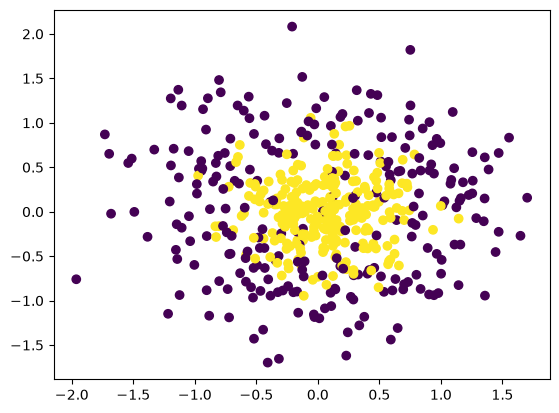

In [89]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt 
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
plt.scatter(X[:,0],X[:,1],c=y)

In [90]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score , r2_score
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_pred=dt.predict(X_test) 
accuracy_score(y_test,y_pred)

0.86

### Random Forest

In [91]:
from sklearn.ensemble import RandomForestClassifier 
rf=RandomForestClassifier(n_estimators=50 , max_features=0.55 , max_samples=0.25)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test) 
accuracy_score(y_test,y_pred)

0.88

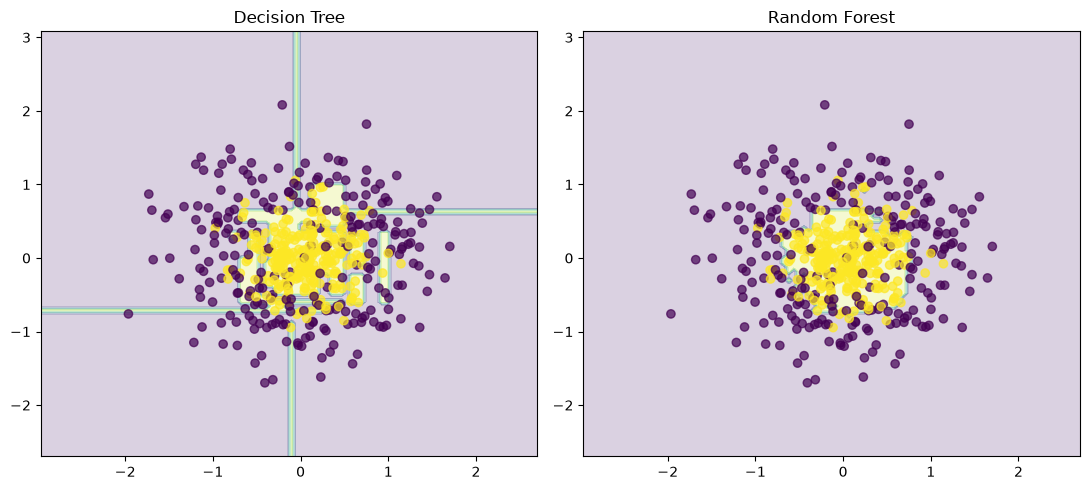

In [92]:
plt.figure(figsize=(11, 5))
ax1 = plt.subplot(1, 2, 1)
DecisionBoundaryDisplay.from_estimator(dt, X_train, response_method="predict", alpha=0.2, ax=ax1)
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", alpha=0.7)
ax1.set_title("Decision Tree")

ax2 = plt.subplot(1, 2, 2)
DecisionBoundaryDisplay.from_estimator(rf, X_train, response_method="predict", alpha=0.2, ax=ax2)
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", alpha=0.7)
ax2.set_title("Random Forest")

plt.tight_layout()
plt.show()

### Using Regression for Both Random Forest and Decision Tree

(-5.0, 5.0)

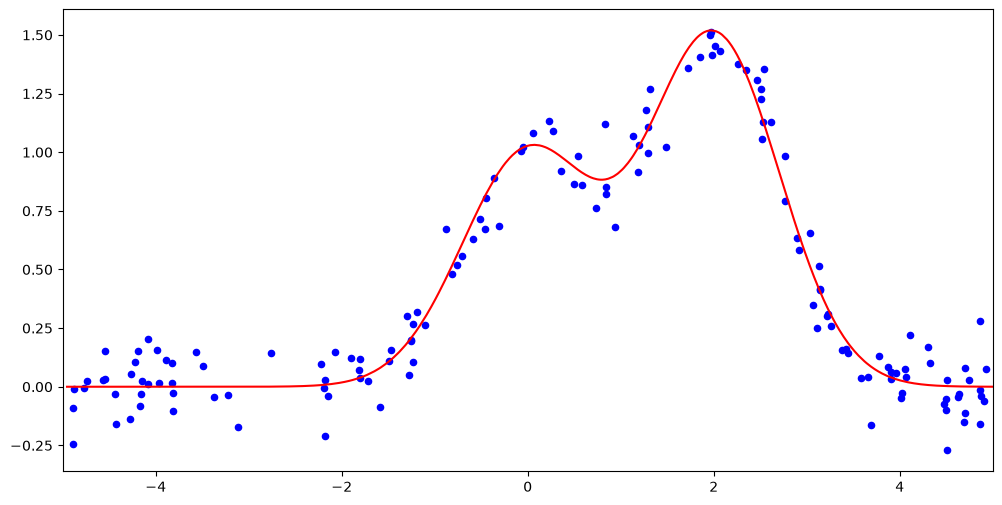

In [93]:
n_train = 150        
n_test = 1000       
noise = 0.1

def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise) 

plt.figure(figsize=(12, 6))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])

In [94]:
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor 
dt=DecisionTreeRegressor() 
dt.fit(X_train,y_train)
y_pred1=dt.predict(X_test) 
print("r2_socre of Decision Tree" , r2_score(y_test,y_pred1)) 

rf=RandomForestRegressor(n_estimators=50 , max_features=0.55 , max_samples=0.25)
rf.fit(X_train,y_train)
y_pred2=rf.predict(X_test) 
print("r2_score of Random Forest",r2_score(y_test,y_pred2))

r2_socre of Decision Tree 0.9108302305907692
r2_score of Random Forest 0.9581491682392281


Text(0.5, 1.0, 'Decision tree, MSE = 11.67')

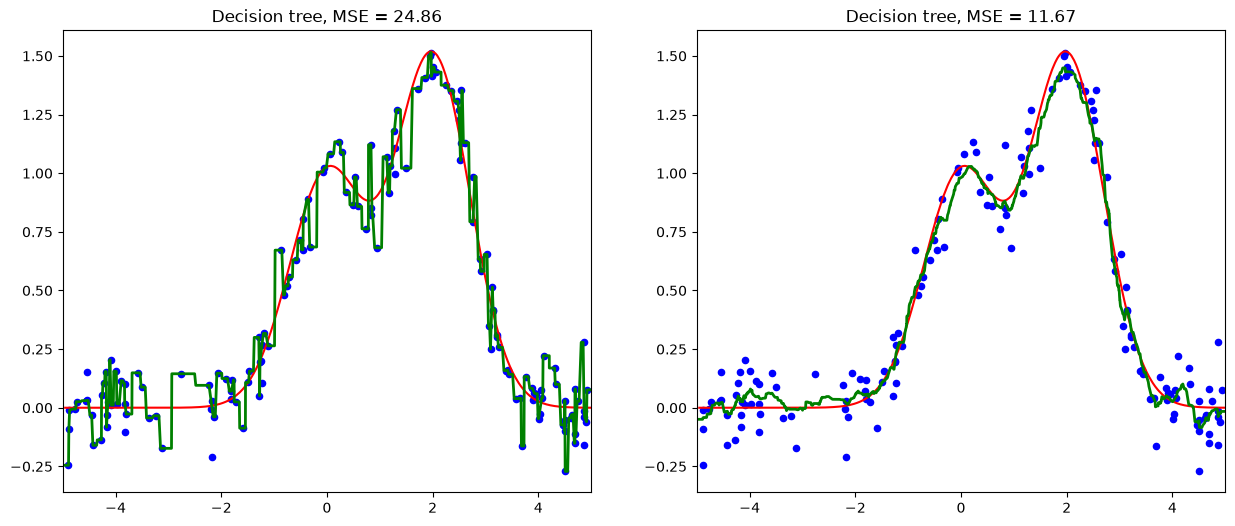

In [95]:
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, y_pred1, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f" 
          % np.sum((y_test - y_pred1) ** 2)) 

plt.subplot(1,2,2)
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, y_pred2, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f" 
          % np.sum((y_test - y_pred2) ** 2))

### Difference Between Bagging and Random Forest

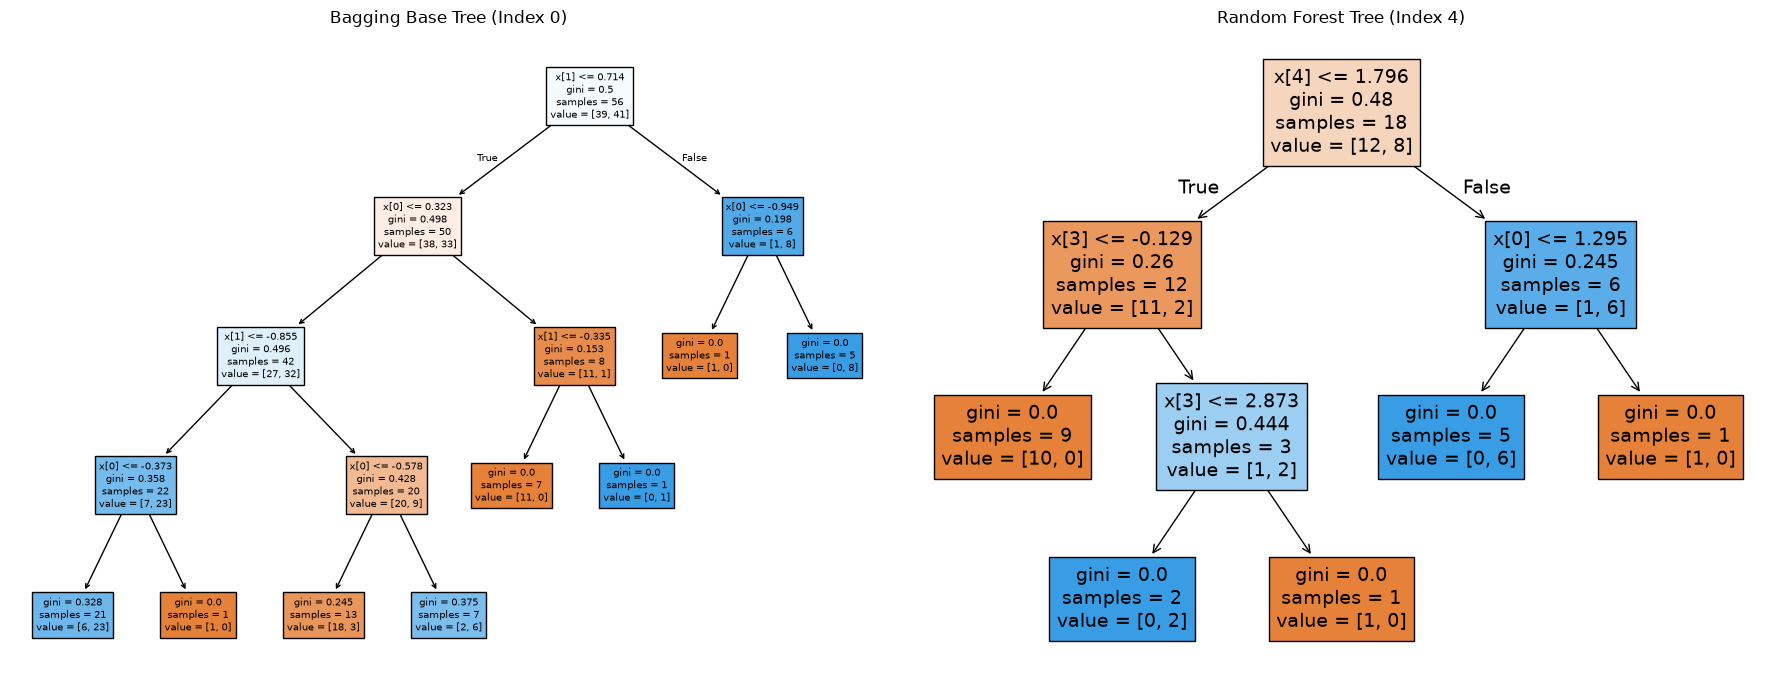

In [97]:
from sklearn.tree import plot_tree
from sklearn.ensemble import BaggingClassifier
from sklearn.datasets import make_classification
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
bag=BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=4) , max_features=2) 

rf=RandomForestClassifier(n_estimators=50 , max_features=0.55 , max_samples=0.25) 
rf.fit(X_train ,y_train)
bag.fit(X_train , y_train)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plot_tree(bag.estimators_[0], filled=True, ax=ax1)
ax1.set_title("Bagging Base Tree (Index 0)")

plot_tree(rf.estimators_[4], filled=True, ax=ax2)
ax2.set_title("Random Forest Tree (Index 4)")
plt.tight_layout()
plt.show()   

### OOB Score

In [99]:
rf=RandomForestClassifier(n_estimators=50 , max_features=0.55 , max_samples=0.25 , oob_score=True)
rf.fit(X_train , y_train) 
print("OBB socre is ",rf.oob_score_)
y_pred = rf.predict(X_test)
print("Accuracy Score is ",accuracy_score(y_test,y_pred))

OBB socre is  0.7625
Accuracy Score is  0.65


### Feature Importance 

In [103]:
sorted(rf.feature_importances_)

[np.float64(0.1339374013817578),
 np.float64(0.13439103845207245),
 np.float64(0.1397845901274027),
 np.float64(0.148930261807108),
 np.float64(0.4429567082316591)]

In [101]:
sum(rf.feature_importances_)  # total must 1

np.float64(1.0)

In [104]:
dt.feature_importances_

array([1.])